# SAE Feature Steering eliability on GPT-2 small
Question: does per-sample FVU (fraction of variance unexplained), the reliability
diagnostic VS2 (Chatzoudis et al. 2026) uses for vision steering, predict when SAE-feature
steering on a language model causes collateral capability damage?

In [1]:
!pip install -q transformer_lens sae-lens datasets

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 85.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 91.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.7/334.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.7/241.7 kB 19.5 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sae_lens import SAE, HookedSAETransformer
from transformers import pipeline
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device, torch.cuda.get_device_name(0) if device == "cuda" else "no gpu")

SEEDS = [0, 1, 2]  

cuda Tesla T4


In [3]:
model = HookedSAETransformer.from_pretrained_no_processing("gpt2", device=device)
model.eval()
print(model.cfg.n_layers, model.cfg.d_model)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
12 768


In [4]:
def load_sae(layer):
    sae_id = f"blocks.{layer}.hook_resid_pre"
    loaded = SAE.from_pretrained(release="gpt2-small-res-jb", sae_id=sae_id, device=device)
    sae = loaded[0] if isinstance(loaded, tuple) else loaded  # handles both old and new API
    sae.eval()
    return sae, sae_id

def compute_fvu(acts, recon):
    return (((acts - recon) ** 2).sum() / ((acts - acts.mean(dim=(0, 1), keepdim=True)) ** 2).sum()).item()

def get_feature_max(sae, hook_name, feature_id, texts, n=100):
    vals = []
    for t in texts[:n]:
        toks = model.to_tokens(t)[:, :64]
        with torch.no_grad():
            _, cache = model.run_with_cache(toks, names_filter=hook_name)
            f = sae.encode(cache[hook_name])[..., feature_id]
        vals.append(f[:, 1:].max().item() if f.shape[1] > 1 else 0.0)
    return max(vals) if vals else 1.0

def get_feature_density(sae, hook_name, feature_id, texts, n=100, threshold=1e-6):
    fires, total = 0, 0
    for t in texts[:n]:
        toks = model.to_tokens(t)[:, :64]
        with torch.no_grad():
            _, cache = model.run_with_cache(toks, names_filter=hook_name)
            f = sae.encode(cache[hook_name])[..., feature_id][:, 1:]  
        total += f.numel()
        fires += (f > threshold).sum().item()
    return fires / total if total > 0 else 0.0

sae, hook_name = load_sae(6)  
print(hook_name)
print("d_in:", sae.W_enc.shape[0], "d_sae:", sae.W_enc.shape[1])

cfg.json: 0.00B [00:00, ?B/s]

blocks.6.hook_resid_pre/sae_weights.safe(…):   0%|          | 0.00/151M [00:00<?, ?B/s]

blocks.6.hook_resid_pre/sparsity.safeten(…):   0%|          | 0.00/98.4k [00:00<?, ?B/s]

blocks.6.hook_resid_pre
d_in: 768 d_sae: 24576


/usr/local/lib/python3.12/dist-packages/sae_lens/saes/sae.py:254: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


In [5]:
sample_text = [
    "The movie was absolutely wonderful and I loved every minute of it.",
    "This was a terrible, disappointing experience and I want my money back.",
    "The weather today is mild with a chance of rain in the afternoon.",
]
tokens = model.to_tokens(sample_text)
_, cache = model.run_with_cache(tokens, names_filter=hook_name)
acts = cache[hook_name][:, 1:, :]  
with torch.no_grad():
    recon = sae.decode(sae.encode(acts))
sanity_fvu = compute_fvu(acts, recon)
print("sanity-check FVU:", sanity_fvu)
assert 0 <= sanity_fvu <= 1.5, (
    f"FVU={sanity_fvu:.2f} is outside a plausible range for this SAE/layer. Real values for "
    "gpt2-small-res-jb tend to land roughly 0.4-1.0 depending on sample size (this sanity "
    "check only uses 3 short sentences, so some noise is expected) -- but this far outside "
    "that range usually means a real problem (wrong hook site, wrong SAE release/id, or the "
    "SAE failed to load real weights). Stop and debug before running anything else."
)


sanity-check FVU: 1.2367303371429443


In [6]:
# Cell 6 -- sentiment data for feature discovery + a larger unlabeled pool for candidate inspection
sst2 = load_dataset("sst2", split="train[:2000]")
pos_texts_all = [x["sentence"] for x in sst2 if x["label"] == 1]
neg_texts_all = [x["sentence"] for x in sst2 if x["label"] == 0]

wikitext = load_dataset("wikitext", "wikitext-103-raw-v1", split="train[:5000]")
pool_texts_all = [t for t in wikitext["text"] if len(t.split()) > 5]
print(len(pos_texts_all), len(neg_texts_all), len(pool_texts_all))


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

wikitext-103-raw-v1/validation-00000-of-(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

1101 899 2899


In [7]:
def get_last_token_feats(sae, hook_name, texts, batch_size=16):
    feats = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        toks = model.to_tokens(batch, padding_side="left")
        with torch.no_grad():
            _, cache = model.run_with_cache(toks, names_filter=hook_name)
            f = sae.encode(cache[hook_name][:, -1, :])
        feats.append(f.cpu())
    return torch.cat(feats, dim=0)

def find_candidate_features(sae, hook_name, n_features=4, n_oversample=40, liveness_pool_size=150):
    pos_feats = get_last_token_feats(sae, hook_name, pos_texts_all[:200])
    neg_feats = get_last_token_feats(sae, hook_name, neg_texts_all[:200])
    diff = pos_feats.mean(0) - neg_feats.mean(0)

    ranked = torch.topk(diff, n_oversample).indices.tolist()
    live = []
    for feat in ranked:
        fmax = get_feature_max(sae, hook_name, feat, pool_texts_all[:liveness_pool_size])
        if fmax > 1e-3:  
            live.append(feat)
        if len(live) >= n_features:
            break
    if len(live) < n_features:
        print(f"WARNING: only found {len(live)} live features out of {n_oversample} candidates checked; "
              f"consider raising n_oversample or checking a different layer.")
    return live

CANDIDATE_FEATURES = find_candidate_features(sae, hook_name)
print("candidate features (layer 6):", CANDIDATE_FEATURES)


candidate features (layer 6): [14244, 19764, 23580, 5235]


In [8]:
def top_activating_examples(sae, hook_name, feature_id, texts, k=5):
    scores = []
    for t in texts[:300]:
        toks = model.to_tokens(t)[:, :64]
        with torch.no_grad():
            _, cache = model.run_with_cache(toks, names_filter=hook_name)
            f = sae.encode(cache[hook_name])[0, :, feature_id]
        scores.append(f[1:].max().item() if f.shape[0] > 1 else 0.0)
    order = np.argsort(scores)[::-1][:k]
    return [(texts[i], round(scores[i], 2)) for i in order]

for feat in CANDIDATE_FEATURES:
    print(f"--- feature {feat} ---")
    for txt, score in top_activating_examples(sae, hook_name, feat, pool_texts_all):
        print(f"  [{score}] {txt[:120]}")


--- feature 14244 ---
  [1.63]  Kurt and Riela were featured in the Nintendo 3DS crossover Project X Zone , representing the Valkyria series . Media.Vi
  [1.25]  Troops are divided into five classes : Scouts , Shocktroopers , Engineers , Lancers and Armored Soldier . Troopers can 
  [1.16]  Barker was equally proficient in watercolour , pen and ink , oils , and pastels . Kate Greenaway and the Pre @-@ Raphae
  [1.04]  Barker 's sketches , drawings , and paintings of children were given to friends or to the parents of the subjects , don
  [1.02]  With the losing continuing , more rumors began to surface . Unlike before , the rumors were about player moves rather t
--- feature 19764 ---
  [8.59]  The soldiers would be allowed to march away as men leaving under orders , not as conquered and surrendering soldiers . 
  [8.02]  752 packages of ordnance and ordnance stores received and mostly issued to troops in service . 

  [7.55]  The arsenal was briefly seized once more by Joseph Brooks l

In [9]:
# Cell 9 -- clamping hook (Templeton et al. method: replace SAE(x), keep error(x) fixed)
def make_clamp_hook(sae, feature_id, clamp_value):
    def hook(resid, hook):
        feats = sae.encode(resid)
        recon = sae.decode(feats)
        error = resid - recon
        feats_clamped = feats.clone()
        feats_clamped[..., feature_id] = clamp_value
        recon_clamped = sae.decode(feats_clamped)
        return recon_clamped + error
    return hook

CLAMP_MULTIPLES = [0, 2, 5, 10]  # multiples of each feature's own observed max, per Templeton et al.


In [10]:
sentiment_clf = pipeline("sentiment-analysis", device=0 if device == "cuda" else -1)

def generate(prompt, hooks, max_new_tokens=25, seed=0):
    torch.manual_seed(seed)
    toks = model.to_tokens(prompt)
    with torch.no_grad():
        if hooks:
            with model.hooks(fwd_hooks=hooks):
                out = model.generate(toks, max_new_tokens=max_new_tokens, do_sample=True, temperature=0.8)
        else:
            out = model.generate(toks, max_new_tokens=max_new_tokens, do_sample=True, temperature=0.8)
    return model.to_string(out[0])[len(prompt):]

ALL_PROMPTS = [
    "I went to the store and", "The new restaurant downtown is", "My weekend plans include",
    "The book I just finished was", "Walking through the park, I noticed",
    "During the meeting, everyone", "The final scene of the film", "After the long drive, we",
]


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [11]:
def run_sweep(sae, hook_name, layer_label, candidate_features, seeds=SEEDS):
    feature_max = {f: get_feature_max(sae, hook_name, f, pool_texts_all) for f in candidate_features}
    feature_density = {f: get_feature_density(sae, hook_name, f, pool_texts_all) for f in candidate_features}
    print(f"[{layer_label}] observed max activations:", feature_max)
    print(f"[{layer_label}] activation density (per-feature, genuinely varies):", feature_density)

    records = []
    for seed in seeds:
        rng = np.random.default_rng(seed)
        prompt_subset = list(rng.choice(ALL_PROMPTS, size=5, replace=False))
        unrelated_subset = list(rng.choice(pool_texts_all, size=40, replace=False))

        for feat in candidate_features:
            fmax = feature_max[feat]
            for mult in CLAMP_MULTIPLES:
                clamp_value = mult * fmax
                hooks = [] if mult == 0 else [(hook_name, make_clamp_hook(sae, feat, clamp_value))]

                sent_scores = []
                for p in prompt_subset:
                    text = generate(p, hooks, seed=seed)
                    res = sentiment_clf(text[:200] if text.strip() else "neutral")[0]
                    signed = res["score"] if res["label"] == "POSITIVE" else -res["score"]
                    sent_scores.append(signed)

                losses = []
                for t in unrelated_subset:
                    toks = model.to_tokens(t)[:, :64]
                    if toks.shape[1] < 2:
                        continue
                    with torch.no_grad():
                        loss = model.run_with_hooks(toks, fwd_hooks=hooks, return_type="loss")
                    losses.append(loss.item())
                ppl = float(np.exp(np.mean(losses)))

                fvu_vals = []
                for t in unrelated_subset[:20]:
                    toks = model.to_tokens(t)[:, :64]
                    with torch.no_grad():
                        _, cache = model.run_with_cache(toks, names_filter=hook_name)
                        a = cache[hook_name][:, 1:, :]  # exclude BOS position, same fix as cell 5
                        r = sae.decode(sae.encode(a))
                    fvu_vals.append(compute_fvu(a, r))

                records.append({
                    "layer": layer_label, "seed": seed, "feature": feat, "clamp_mult": mult,
                    "mean_sentiment": np.mean(sent_scores), "std_sentiment": np.std(sent_scores),
                    "perplexity": ppl, "fvu": np.mean(fvu_vals),
                    "activation_density": feature_density[feat],  # constant per feature, varies BY feature
                })
    return pd.DataFrame(records)

results_df = run_sweep(sae, hook_name, "layer6", CANDIDATE_FEATURES)
results_df.to_csv("/kaggle/working/steering_results_layer6.csv", index=False)
results_df.head(20)


[layer6] observed max activations: {14244: 1.6316266059875488, 19764: 8.59029483795166, 23580: 19.649965286254883, 5235: 6.286679267883301}
[layer6] activation density (per-feature, genuinely varies): {14244: 0.010090167453842851, 19764: 0.004293688278231, 23580: 0.0098754830399313, 5235: 0.0066552168312580505}


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

,layer,seed,feature,clamp_mult,mean_sentiment,std_sentiment,perplexity,fvu,activation_density
0,layer6,0,14244,0,-0.583323,0.790792,95.260988,0.608159,0.010090
1,layer6,0,14244,2,-0.510422,0.772010,92.907798,0.608159,0.010090
2,layer6,0,14244,5,0.289146,0.878552,93.109383,0.608159,0.010090
3,layer6,0,14244,10,-0.295484,0.648500,93.889464,0.608159,0.010090
4,layer6,0,19764,0,-0.583323,0.790792,95.260988,0.608159,0.004294
5,layer6,0,19764,2,-0.060327,0.875178,109.246765,0.608159,0.004294
6,layer6,0,19764,5,0.985066,0.017644,226.127725,0.608159,0.004294
7,layer6,0,19764,10,-0.981860,0.022887,2528.081902,0.608159,0.004294
8,layer6,0,23580,0,-0.583323,0.790792,95.260988,0.608159,0.009875
9,layer6,0,23580,2,-0.196103,0.950896,134.412538,0.608159,0.009875


In [12]:
# Cell 12 -- aggregation helper (reusable across layers) + run for layer 6
def aggregate(results_df):
    agg = results_df.groupby(["layer", "feature", "clamp_mult"]).agg(
        sentiment_mean=("mean_sentiment", "mean"), sentiment_std=("mean_sentiment", "std"),
        perplexity_mean=("perplexity", "mean"), perplexity_std=("perplexity", "std"),
        fvu_mean=("fvu", "mean"), activation_density=("activation_density", "mean"),
    ).reset_index()
    return agg

def summarize_features(agg, layer_label, max_clamp):
    sub = agg[agg["layer"] == layer_label]
    baseline_ppl = sub[sub["clamp_mult"] == 0].set_index("feature")["perplexity_mean"]
    strong_ppl = sub[sub["clamp_mult"] == max_clamp].set_index("feature")["perplexity_mean"]
    collateral_damage = (strong_ppl - baseline_ppl).rename("ppl_increase_at_max_clamp")
    # NOTE: baseline_fvu (measured at clamp_mult=0, i.e. unsteered) is a property of the
    # (SAE, layer, text sample) only -- it does NOT vary by feature and will be constant
    # across every row here. Keep it as a diagnostic, but activation_density is the real
    # per-feature reliability axis for the correlation test below.
    fvu_by_feature = sub[sub["clamp_mult"] == 0].set_index("feature")["fvu_mean"].rename("baseline_fvu")
    density_by_feature = sub[sub["clamp_mult"] == 0].set_index("feature")["activation_density"].rename("activation_density")
    out = pd.concat([collateral_damage, fvu_by_feature, density_by_feature], axis=1)
    out["layer"] = layer_label
    return out

agg = aggregate(results_df)
feature_summary = summarize_features(agg, "layer6", CLAMP_MULTIPLES[-1])
feature_summary


,ppl_increase_at_max_clamp,baseline_fvu,activation_density,layer
feature,,,,
5235,3442.572320,0.607949,0.006655,layer6
14244,-0.054031,0.607949,0.010090,layer6
19764,2534.657387,0.607949,0.004294,layer6
23580,34284.389182,0.607949,0.009875,layer6


In [13]:
from scipy.stats import spearmanr

def reliability_collateral_permtest(feature_summary, x_col="activation_density", n_perms=1000, seed=0):
    vals_a = feature_summary[x_col].values
    vals_b = feature_summary["ppl_increase_at_max_clamp"].values
    observed, _ = spearmanr(vals_a, vals_b)
    rng = np.random.default_rng(seed)
    perm_corrs = [spearmanr(vals_a, rng.permutation(vals_b))[0] for _ in range(n_perms)]
    p_value = np.mean(np.abs(perm_corrs) >= abs(observed))
    return observed, p_value, len(feature_summary)

observed, p_value, n = reliability_collateral_permtest(feature_summary)
print(f"[layer6] Spearman r (density vs collateral) = {observed:.3f}, permutation p = {p_value:.3f}, n_features = {n}")
print("With this few features, treat this as suggestive, not confirmatory -- report both numbers.")


[layer6] Spearman r (density vs collateral) = -0.200, permutation p = 0.927, n_features = 4
With this few features, treat this as suggestive, not confirmatory -- report both numbers.


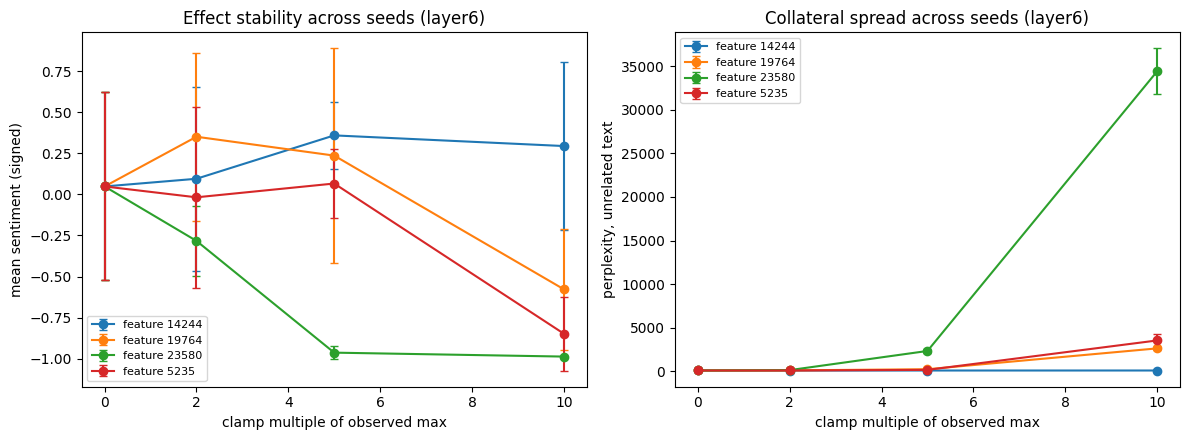

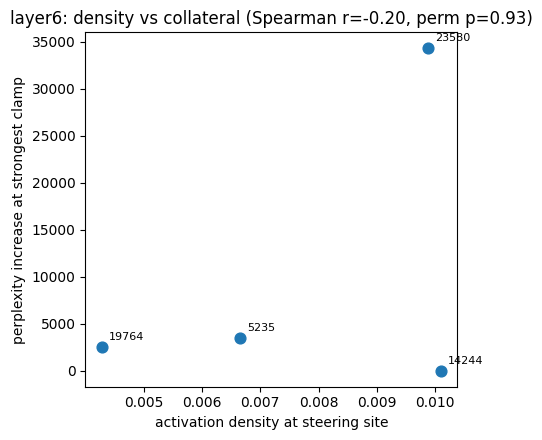

In [14]:
def plot_effect_and_collateral(agg, layer_label, candidate_features, save_path):
    sub = agg[agg["layer"] == layer_label]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for feat in candidate_features:
        s = sub[sub["feature"] == feat]
        axes[0].errorbar(s["clamp_mult"], s["sentiment_mean"], yerr=s["sentiment_std"],
                          marker="o", capsize=3, label=f"feature {feat}")
        axes[1].errorbar(s["clamp_mult"], s["perplexity_mean"], yerr=s["perplexity_std"],
                          marker="o", capsize=3, label=f"feature {feat}")
    axes[0].set_xlabel("clamp multiple of observed max"); axes[0].set_ylabel("mean sentiment (signed)")
    axes[0].set_title(f"Effect stability across seeds ({layer_label})"); axes[0].legend(fontsize=8)
    axes[1].set_xlabel("clamp multiple of observed max"); axes[1].set_ylabel("perplexity, unrelated text")
    axes[1].set_title(f"Collateral spread across seeds ({layer_label})"); axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

def plot_density_vs_collateral(feature_summary, observed, p_value, layer_label, save_path):
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.scatter(feature_summary["activation_density"], feature_summary["ppl_increase_at_max_clamp"], s=60)
    for feat, row in feature_summary.iterrows():
        ax.annotate(str(feat), (row["activation_density"], row["ppl_increase_at_max_clamp"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)
    ax.set_xlabel("activation density at steering site"); ax.set_ylabel("perplexity increase at strongest clamp")
    ax.set_title(f"{layer_label}: density vs collateral (Spearman r={observed:.2f}, perm p={p_value:.2f})")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

plot_effect_and_collateral(agg, "layer6", CANDIDATE_FEATURES, "/kaggle/working/layer6_effect_collateral.png")
plot_density_vs_collateral(feature_summary, observed, p_value, "layer6", "/kaggle/working/layer6_density_vs_collateral.png")


In [15]:
sae_l9, hook_name_l9 = load_sae(9)
candidate_features_l9 = find_candidate_features(sae_l9, hook_name_l9)
print("candidate features (layer 9):", candidate_features_l9)

for feat in candidate_features_l9:
    print(f"--- layer9 feature {feat} ---")
    for txt, score in top_activating_examples(sae_l9, hook_name_l9, feat, pool_texts_all):
        print(f"  [{score}] {txt[:120]}")

results_df_l9 = run_sweep(sae_l9, hook_name_l9, "layer9", candidate_features_l9)
results_df_l9.to_csv("/kaggle/working/steering_results_layer9.csv", index=False)


cfg.json: 0.00B [00:00, ?B/s]

blocks.9.hook_resid_pre/sae_weights.safe(…):   0%|          | 0.00/151M [00:00<?, ?B/s]

blocks.9.hook_resid_pre/sparsity.safeten(…):   0%|          | 0.00/98.4k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/sae_lens/saes/sae.py:254: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


candidate features (layer 9): [4915, 23954, 24284, 14150]
--- layer9 feature 4915 ---
  [3.1]  The development of women 's football in Africa faces several challenges , including limited access to education , pover
  [1.45]  Gambia 's national football association was founded in 1952 , and became affiliated with FIFA in 1968 . Football is the
  [1.44]  M1855 .58 cal rifle @-@ muskets 900 

  [1.41]  Troops are divided into five classes : Scouts , Shocktroopers , Engineers , Lancers and Armored Soldier . Troopers can 
  [1.23]  The Sundial Room , also called the Meridian Hall , was once the residence of Queen Christina of Sweden , then newly con
--- layer9 feature 23954 ---
  [19.71]  The soldiers would be allowed to march away as men leaving under orders , not as conquered and surrendering soldiers . 
  [19.08]  The soldiers would be allowed safe passage in any direction carrying any personal and public property besides munitions
  [18.81]  752 packages of ordnance and ordnance stores 

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

[layer9] Spearman r (density vs collateral) = 0.600, permutation p = 0.392, n_features = 4


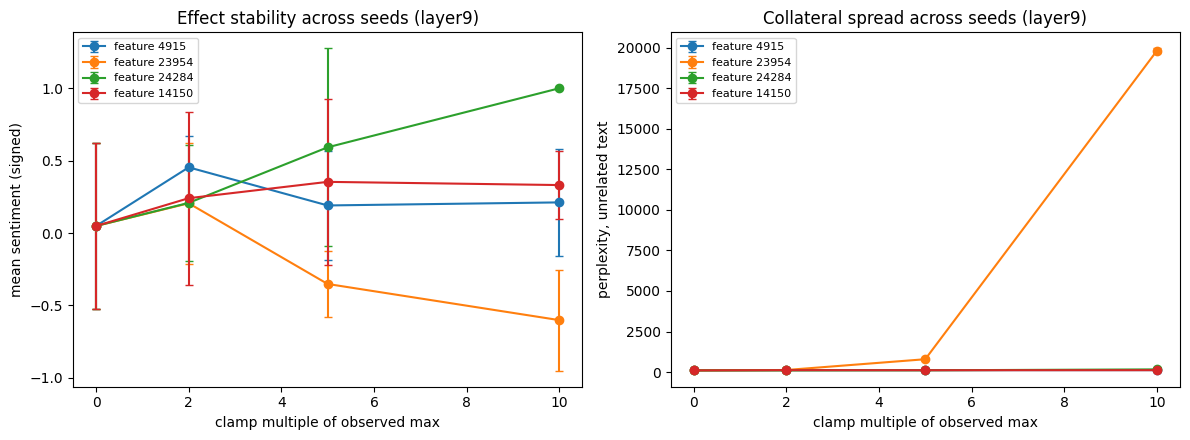

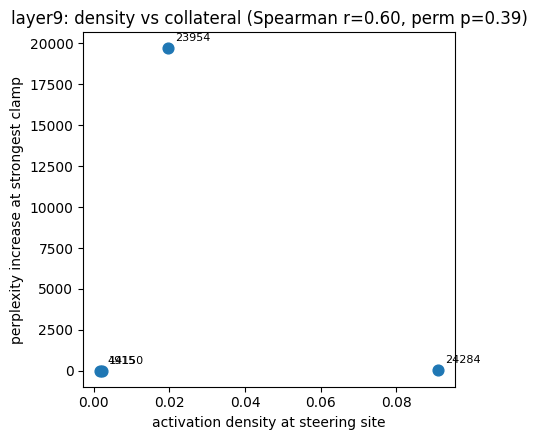

In [16]:
results_all = pd.concat([results_df, results_df_l9], ignore_index=True)
results_all.to_csv("/kaggle/working/steering_results_all_layers.csv", index=False)

agg_all = aggregate(results_all)
feature_summary_l9 = summarize_features(agg_all, "layer9", CLAMP_MULTIPLES[-1])
observed_l9, p_value_l9, n_l9 = reliability_collateral_permtest(feature_summary_l9)
print(f"[layer9] Spearman r (density vs collateral) = {observed_l9:.3f}, permutation p = {p_value_l9:.3f}, n_features = {n_l9}")

plot_effect_and_collateral(agg_all, "layer9", candidate_features_l9, "/kaggle/working/layer9_effect_collateral.png")
plot_density_vs_collateral(feature_summary_l9, observed_l9, p_value_l9, "layer9", "/kaggle/working/layer9_density_vs_collateral.png")


In [17]:
comparison = pd.DataFrame([
    {"layer": "layer6", "spearman_r": observed, "perm_p": p_value, "n_features": n},
    {"layer": "layer9", "spearman_r": observed_l9, "perm_p": p_value_l9, "n_features": n_l9},
])
comparison


,layer,spearman_r,perm_p,n_features
0,layer6,-0.2,0.927,4
1,layer9,0.6,0.392,4
